In [11]:
# Import necessary libraries
import os
import torch
import tifffile
import numpy as np
from batchgeneratorsv2.transforms.spatial.sinusoidal_wave import SineWaveDeformation
from batchgeneratorsv2.transforms.spatial.rotation import ArbitraryRotationTransform

In [12]:
# Functions to load and save TIF files
def load_tif_as_tensor(file_path):
    """Load a TIF file and convert it to a PyTorch tensor."""
    tif_data = tifffile.imread(file_path)

    # Convert to appropriate data type
    if tif_data.dtype == np.uint8 or tif_data.dtype == np.uint16:
        # For images, normalize to [0, 1]
        tif_data = tif_data.astype(np.float32)
        if tif_data.max() > 0:
            tif_data = tif_data / tif_data.max()

    # Convert to PyTorch tensor
    tensor = torch.from_numpy(tif_data)

    # Add channel dimension if not present
    if len(tensor.shape) == 3:  # 3D data without channel
        tensor = tensor.unsqueeze(0)

    return tensor

def save_tensor_as_tif(tensor, file_path, is_label=False):
    """Save a PyTorch tensor as a TIF file."""
    # Convert to numpy
    np_array = tensor.detach().cpu().numpy()

    # Remove channel dimension if only one channel
    if np_array.shape[0] == 1:
        np_array = np_array[0]

    # Convert back to original data type
    if is_label:
        # For labels, convert to integer
        np_array = np_array.astype(np.int32)
    else:
        # For images, convert to float32 or uint16 based on range
        if np_array.max() <= 1.0:
            np_array = (np_array * 65535).astype(np.uint16)
        else:
            np_array = np_array.astype(np.float32)

    # Save as TIF
    tifffile.imwrite(file_path, np_array)

In [13]:
# Set file paths
image_path = "/mnt/raid_nvme/test_datasets/images/s1_00497_02497_02997_256_0000.tif"  # Update with your image path
label_path = "/mnt/raid_nvme/test_datasets/labels/s1_00497_02497_02997_256.tif"  # Update with your label path
output_dir = "test_outputs"  # Update with your output directory

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Generate output filenames
image_basename = os.path.basename(image_path)
label_basename = os.path.basename(label_path)
image_output_path = os.path.join(output_dir, f"deformed_{image_basename}")
label_output_path = os.path.join(output_dir, f"deformed_{label_basename}")

In [14]:
# Load TIF files as tensors
image_tensor = load_tif_as_tensor(image_path)
label_tensor = load_tif_as_tensor(label_path)

# Create data dictionary
data_dict = {
    'image': image_tensor,
    'segmentation': label_tensor
}

# Create and apply the sine wave deformation
# transform = SineWaveDeformation(
#     min_peaks=1,
#     max_peaks=2,
#     min_magnitude=0.0,
#     max_magnitude=0.75,
#     boundary_mode='constant',  # Try 'constant', 'nearest', 'reflect', or 'mirror'
#     constant_value=0.5,  # Fill value when boundary_mode is 'constant'
#     single_axis=True,  # Use same random axis for all waves
#     fixed_axis=0  # Use X axis (0) for waves. Set to None for random axis selection.
# )

transform = ArbitraryRotationTransform(
        rotation_angle_range=(-np.pi/8, np.pi/8),  # +/- 15 degrees
        p_per_axis=0.5  # 80% chance of rotation per axis
    )

# Apply transformation
transformed_dict = transform(**data_dict)

In [15]:
# Save the transformed data
save_tensor_as_tif(transformed_dict['image'], image_output_path)
save_tensor_as_tif(transformed_dict['segmentation'], label_output_path, is_label=True)

print(f"Deformed image saved to: {image_output_path}")
print(f"Deformed label saved to: {label_output_path}")

Deformed image saved to: test_outputs/deformed_s1_00497_02497_02997_256_0000.tif
Deformed label saved to: test_outputs/deformed_s1_00497_02497_02997_256.tif


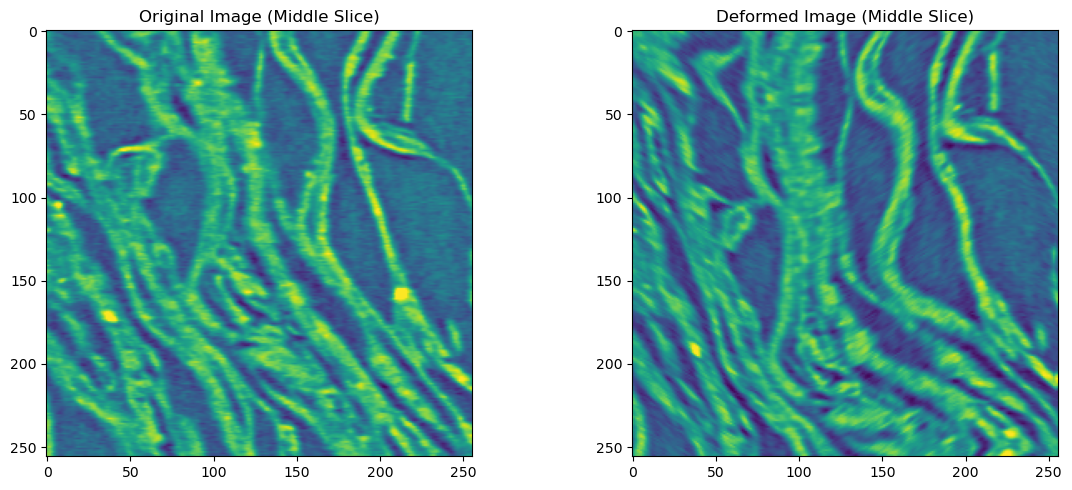

In [10]:
# Optional: Visualize a slice (if you have matplotlib)
import matplotlib.pyplot as plt

# Visualize original and deformed image (middle slice)
if len(image_tensor.shape) == 4:  # 3D with channel
    z_mid = image_tensor.shape[2] // 2
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_tensor[0, :, z_mid, :].numpy())
    plt.title('Original Image (Middle Slice)')

    plt.subplot(1, 2, 2)
    plt.imshow(transformed_dict['image'][0, :, z_mid, :].numpy())
    plt.title('Deformed Image (Middle Slice)')

    plt.tight_layout()
    plt.show()